In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Gensim
import gensim
from gensim import corpora
from gensim.models import LdaModel

import joblib

# Reload data
df = pd.read_csv('/home/guts/mental_health_nlp/data/preprocessed.csv')
print("Data loaded:", df.shape)

# Rebuild TF-IDF + LSA
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned'])
print("TF-IDF:", X.shape)

svd = TruncatedSVD(n_components=100, random_state=42)
normalizer = Normalizer(copy=False)
lsa = make_pipeline(svd, normalizer)
X_lsa = lsa.fit_transform(X)
print("LSA:", X_lsa.shape)

# Reload tokenized for LDA
tokenized = df['cleaned'].apply(lambda x: x.split())
dictionary = corpora.Dictionary(tokenized)
dictionary.filter_extremes(no_below=10, no_above=0.4)
corpus = [dictionary.doc2bow(doc) for doc in tokenized]
print("LDA corpus ready")

# Reload saved models
kmeans_final = joblib.load('/home/guts/mental_health_nlp/models/kmeans_final.pkl')
lda_final = LdaModel.load('/home/guts/mental_health_nlp/models/lda_final')
print("Models loaded")

print("\nEverything ready!")

Data loaded: (52484, 4)
TF-IDF: (52484, 5000)
LSA: (52484, 100)
LDA corpus ready
Models loaded

Everything ready!


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/home/guts/mental_health_nlp/data/Combined Data.csv")

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (53043, 3)

Columns: ['Unnamed: 0', 'statement', 'status']

First 5 rows:


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [2]:
# Check the mental health categories
print("Mental health categories:")
print(df['status'].value_counts())

print("\nAny missing values?")
print(df.isnull().sum())

print("\nExample statements:")
for i, row in df.sample(5, random_state=42).iterrows():
    print(f"\n[{row['status']}]: {row['statement'][:150]}")

Mental health categories:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

Any missing values?
Unnamed: 0      0
statement     362
status          0
dtype: int64

Example statements:

[Depression]: Just as the the title says. I feel like one is hyper alot, a attention whore, and is idealistic and stupid. and the other is calm, trys to be normal, 

[Depression]: a blackened sky encroached tugging behind it my depression

[Depression]: It gives you insomnia, which in turn makes your depression worse during the day, which messes up your sleep even more, which gives you anxiety. It jus

[Normal]: Hello all, I'm a new submitter to this channel. I went here a few nights ago and honestly it's been helping me cope with my current situation by readi

[Normal]: Thank God the CB is over for Eid


In [3]:
# Drop the useless index column
df = df.drop(columns=['Unnamed: 0'])

# Drop rows where statement is missing
df = df.dropna(subset=['statement'])

# Reset the index after dropping rows
df = df.reset_index(drop=True)

# Confirm
print("Shape after cleaning:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Shape after cleaning: (52681, 2)
Missing values: 0


In [4]:
df.to_csv("/home/guts/mental_health_nlp/data/cleaned_raw.csv", index=False)
print("Saved!")

Saved!


In [5]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /home/guts/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/guts/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
import re
import spacy
from nltk.corpus import stopwords

# Load spacy model
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove extra spaces
    text = text.strip()
    
    # Lemmatize + remove stopwords using spacy
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc 
              if token.text not in stop_words 
              and len(token.text) > 2]
    
    return " ".join(tokens)

# Test it on one example first
sample = df['statement'][1]
print("BEFORE:", sample)
print("\nAFTER:", clean_text(sample))

BEFORE: trouble sleeping, confused mind, restless heart. All out of tune

AFTER: trouble sleep confused mind restless heart tune


In [7]:
from tqdm import tqdm
tqdm.pandas()

print("Cleaning all statements... this will take a few minutes.")
df['cleaned'] = df['statement'].progress_apply(clean_text)

print("\nDone!")
print(df[['statement', 'cleaned']].head(3))

Cleaning all statements... this will take a few minutes.


100%|██████████| 52681/52681 [15:42<00:00, 55.90it/s]  



Done!
                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   

                                             cleaned  
0                                               gosh  
1    trouble sleep confused mind restless heart tune  
2  wrong back dear forward doubt stay restless re...  


In [8]:
df.to_csv("/home/guts/mental_health_nlp/data/preprocessed.csv", index=False)
print("Saved preprocessed data!")

Saved preprocessed data!


In [9]:
# Check how many empty strings we got after cleaning
empty = df['cleaned'].str.strip().eq('').sum()
print(f"Empty statements after cleaning: {empty}")

# Check a few more examples
print("\nRandom samples:")
for i, row in df.sample(5, random_state=1).iterrows():
    print(f"\n[{row['status']}]: {row['cleaned'][:120]}")

Empty statements after cleaning: 197

Random samples:

[Depression]: bad anxiety debilitate able keep job since pretty much ever wake early morning hour heart race black puke cough body sha

[Normal]: jessica star musical legally blonde elle wood female lead drama

[Depression]: tired see point suffering understand want know do wrong deserve everything say sorry anything make stop already burial p

[Suicidal]: life year ago completely different chick magnet everyone love many friend past year lose everything friend feel sad anyo

[Suicidal]: noonespecixl know one enjoy company make everyone miserable everyone well


In [10]:
# Drop empty cleaned statements
df = df[df['cleaned'].str.strip() != '']
df = df.reset_index(drop=True)

print("Shape after dropping empty:", df.shape)

# Save the final clean version
df.to_csv("/home/guts/mental_health_nlp/data/preprocessed.csv", index=False)
print("Saved!")

Shape after dropping empty: (52484, 3)
Saved!


In [11]:
import gensim
from gensim import corpora
from gensim.models import LdaModel
import warnings
warnings.filterwarnings('ignore')

# Tokenize cleaned text (split each statement into a list of words)
tokenized = df['cleaned'].apply(lambda x: x.split())

# Build dictionary (maps each unique word to an ID)
dictionary = corpora.Dictionary(tokenized)

# Filter out very rare and very common words
dictionary.filter_extremes(no_below=10, no_above=0.4)

# Convert each statement into bag-of-words format
corpus = [dictionary.doc2bow(doc) for doc in tokenized]

print("Dictionary size:", len(dictionary))
print("Corpus size:", len(corpus))
print("\nExample (first statement as bag of words):")
print(corpus[0][:10], "← (word_id, count) pairs")

Dictionary size: 7697
Corpus size: 52484

Example (first statement as bag of words):
[(0, 1)] ← (word_id, count) pairs


In [12]:
# Train LDA model
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=7,        # 7 topics = matches our 7 mental health categories
    random_state=42,
    passes=10,           # how many times it goes through the data
    alpha='auto',        # learns the best topic distribution automatically
    per_word_topics=True
)

print("LDA model trained!")
print("\nTop words per topic:")
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"\nTopic {idx}: {topic}")

LDA model trained!

Top words per topic:

Topic 0: 0.083*"anxiety" + 0.026*"experience" + 0.018*"pain" + 0.018*"heart" + 0.017*"cause" + 0.017*"doctor" + 0.016*"take" + 0.016*"panic" + 0.016*"med" + 0.015*"anxious"

Topic 1: 0.026*"even" + 0.024*"make" + 0.022*"would" + 0.021*"try" + 0.020*"time" + 0.019*"much" + 0.018*"thing" + 0.017*"friend" + 0.016*"never" + 0.015*"could"

Topic 2: 0.036*"say" + 0.035*"help" + 0.024*"need" + 0.021*"tell" + 0.016*"ask" + 0.015*"anyone" + 0.013*"see" + 0.012*"health" + 0.012*"also" + 0.012*"attack"

Topic 3: 0.053*"get" + 0.037*"go" + 0.033*"day" + 0.024*"work" + 0.024*"start" + 0.021*"year" + 0.021*"bad" + 0.017*"back" + 0.016*"week" + 0.015*"month"

Topic 4: 0.050*"life" + 0.046*"take" + 0.026*"live" + 0.023*"want" + 0.018*"well" + 0.017*"die" + 0.017*"nothing" + 0.016*"one" + 0.016*"care" + 0.016*"everything"

Topic 5: 0.085*"feel" + 0.064*"like" + 0.038*"know" + 0.034*"really" + 0.033*"want" + 0.031*"think" + 0.016*"talk" + 0.014*"depression" + 0.

In [13]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Prepare visualization
vis = gensimvis.prepare(lda_model, corpus, dictionary)

# Save as HTML file you can open in browser
pyLDAvis.save_html(vis, '/home/guts/mental_health_nlp/notebooks/lda_visualization.html')
print("Saved! Open lda_visualization.html in your browser")

Saved! Open lda_visualization.html in your browser


In [14]:
import os
os.makedirs('/home/guts/mental_health_nlp/models', exist_ok=True)
lda_model.save('/home/guts/mental_health_nlp/models/lda_model')
dictionary.save('/home/guts/mental_health_nlp/models/lda_dictionary')
print("Model saved!")

Model saved!


In [15]:
from gensim.models import CoherenceModel

coherence_scores = []
topic_range = range(2, 12)

for num_topics in topic_range:
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        alpha='auto'
    )
    coherence = CoherenceModel(
        model=model, 
        texts=tokenized, 
        dictionary=dictionary, 
        coherence='c_v'
    )
    score = coherence.get_coherence()
    coherence_scores.append(score)
    print(f"Topics: {num_topics} | Coherence: {score:.4f}")

Topics: 2 | Coherence: 0.3806
Topics: 3 | Coherence: 0.3822
Topics: 4 | Coherence: 0.3780
Topics: 5 | Coherence: 0.3462
Topics: 6 | Coherence: 0.3753
Topics: 7 | Coherence: 0.3695
Topics: 8 | Coherence: 0.3638
Topics: 9 | Coherence: 0.3519
Topics: 10 | Coherence: 0.3542
Topics: 11 | Coherence: 0.3574


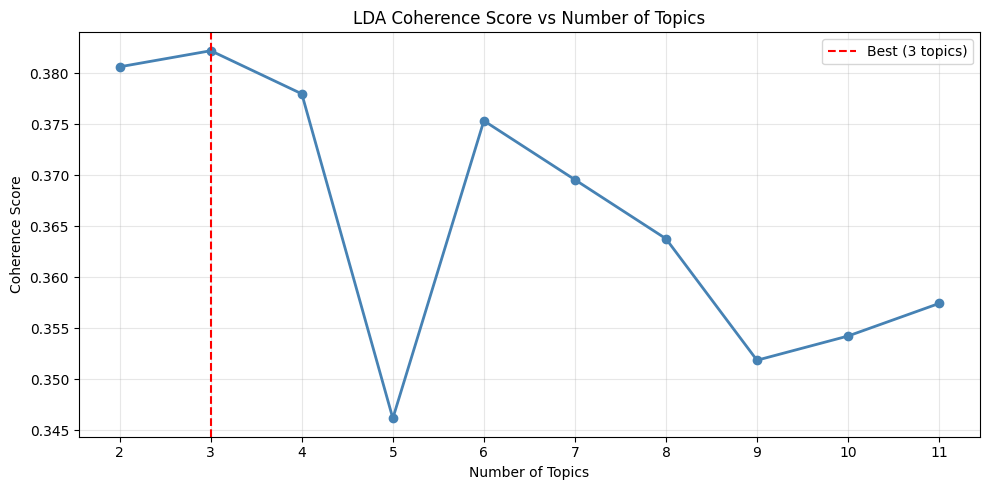

Saved!


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(list(topic_range), coherence_scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')
plt.title('LDA Coherence Score vs Number of Topics')
plt.xticks(list(topic_range))
plt.grid(True, alpha=0.3)
plt.axvline(x=3, color='red', linestyle='--', label='Best (3 topics)')
plt.legend()
plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/coherence_scores.png', dpi=150)
plt.show()
print("Saved!")

In [17]:
# Retrain with optimal number of topics
lda_final = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    random_state=42,
    passes=10,
    alpha='auto'
)

print("Top words per topic:")
for idx, topic in lda_final.print_topics(num_words=12):
    print(f"\nTopic {idx}: {topic}")

Top words per topic:

Topic 0: 0.028*"anxiety" + 0.018*"feel" + 0.017*"get" + 0.014*"take" + 0.011*"day" + 0.011*"like" + 0.010*"start" + 0.010*"go" + 0.008*"bad" + 0.008*"experience" + 0.008*"sleep" + 0.008*"stress"

Topic 1: 0.031*"feel" + 0.029*"like" + 0.021*"want" + 0.018*"know" + 0.016*"life" + 0.015*"people" + 0.014*"think" + 0.014*"even" + 0.014*"get" + 0.014*"make" + 0.012*"thing" + 0.009*"really"

Topic 2: 0.017*"get" + 0.015*"work" + 0.013*"say" + 0.011*"help" + 0.010*"time" + 0.010*"need" + 0.009*"year" + 0.009*"tell" + 0.009*"job" + 0.008*"ask" + 0.008*"go" + 0.008*"would"


In [18]:
# Save final model
lda_final.save('/home/guts/mental_health_nlp/models/lda_final')
print("Model saved!")

# New visualization
vis_final = gensimvis.prepare(lda_final, corpus, dictionary)
pyLDAvis.save_html(vis_final, '/home/guts/mental_health_nlp/notebooks/lda_final_visualization.html')
print("Visualization saved!")

Model saved!
Visualization saved!


In [19]:
# Assign dominant topic to each post
def get_dominant_topic(bow):
    topics = lda_final.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0]

df['dominant_topic'] = [get_dominant_topic(bow) for bow in corpus]

print("Topic distribution:")
print(df['dominant_topic'].value_counts())

df.to_csv('/home/guts/mental_health_nlp/data/preprocessed.csv', index=False)
print("\nSaved!")

Topic distribution:
dominant_topic
1    32134
2    12867
0     7483
Name: count, dtype: int64

Saved!


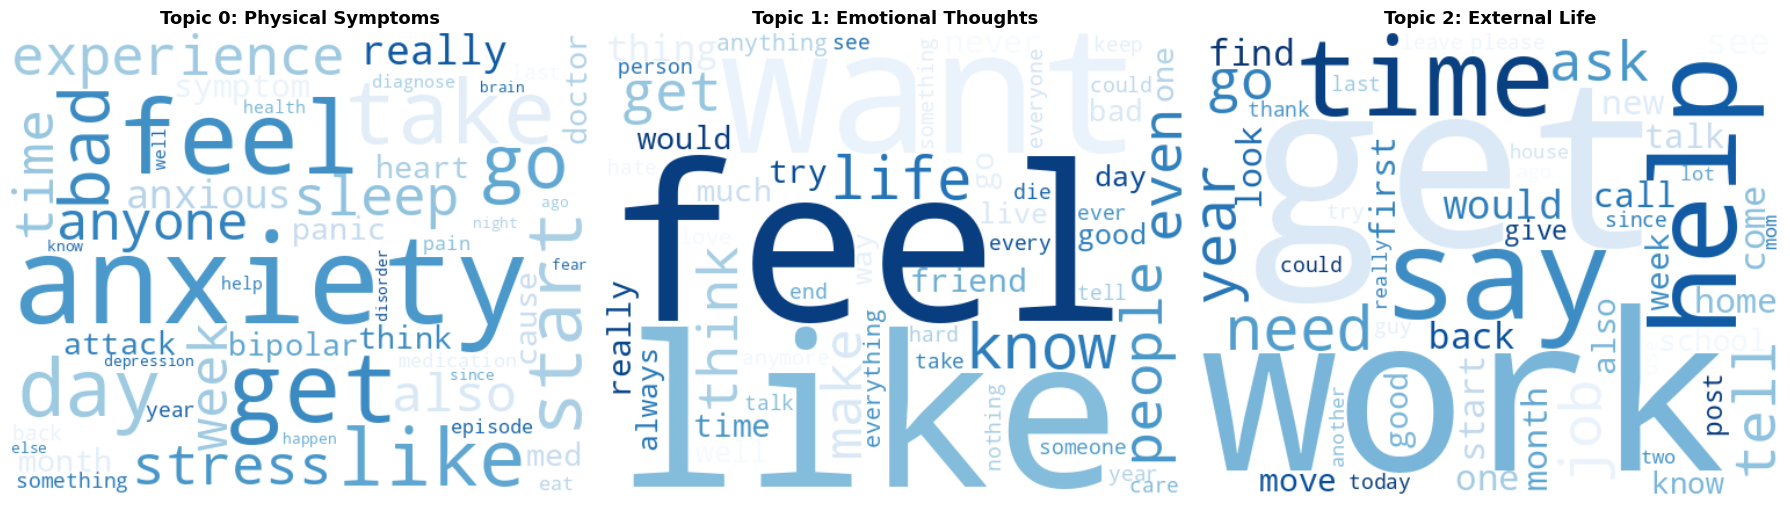

Saved!


In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Topic 0: Physical Symptoms', 
          'Topic 1: Emotional Thoughts', 
          'Topic 2: External Life']

for i in range(3):
    # Get top 50 words for this topic
    words = dict(lda_final.show_topic(i, topn=50))
    
    wc = WordCloud(
        width=500, 
        height=400, 
        background_color='white',
        colormap='Blues'
    ).generate_from_frequencies(words)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/topic_wordclouds.png', dpi=150)
plt.show()
print("Saved!")

In [29]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

# Reduce TF-IDF to 100 dimensions using LSA
svd = TruncatedSVD(n_components=100, random_state=42)
normalizer = Normalizer(copy=False)
lsa = make_pipeline(svd, normalizer)

X_lsa = lsa.fit_transform(X)

print("LSA matrix shape:", X_lsa.shape)

LSA matrix shape: (52484, 100)


In [35]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000)
    kmeans.fit(X_lsa)
    
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_lsa, kmeans.labels_, sample_size=5000, random_state=42)
    silhouette_scores.append(score)
    
    print(f"k={k} | Inertia: {kmeans.inertia_:.0f} | Silhouette: {score:.4f}")

k=2 | Inertia: 43714 | Silhouette: 0.0357
k=3 | Inertia: 43123 | Silhouette: 0.0105
k=4 | Inertia: 42659 | Silhouette: 0.0180
k=5 | Inertia: 42099 | Silhouette: 0.0177
k=6 | Inertia: 41640 | Silhouette: 0.0195
k=7 | Inertia: 41385 | Silhouette: 0.0179
k=8 | Inertia: 41035 | Silhouette: 0.0200
k=9 | Inertia: 40829 | Silhouette: 0.0189
k=10 | Inertia: 40552 | Silhouette: 0.0224


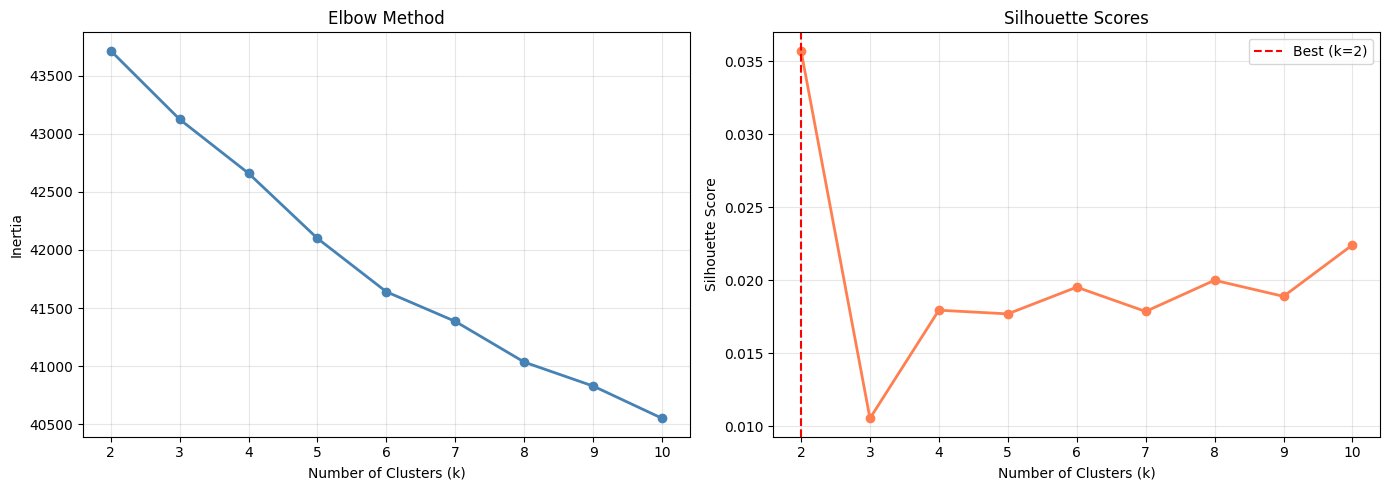

Saved!


In [36]:
# Plot elbow and silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), silhouette_scores, marker='o', color='coral', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores')
ax2.axvline(x=2, color='red', linestyle='--', label='Best (k=2)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/kmeans_evaluation.png', dpi=150)
plt.show()
print("Saved!")

In [37]:
# Train final KMeans with k=2
kmeans_final = MiniBatchKMeans(n_clusters=2, random_state=42, batch_size=1000)
kmeans_final.fit(X_lsa)

# Add cluster labels to dataframe
df['cluster'] = kmeans_final.labels_

print("Cluster distribution:")
print(df['cluster'].value_counts())

print("\nCluster vs Mental Health Status:")
print(pd.crosstab(df['cluster'], df['status']))

Cluster distribution:
cluster
1    27049
0    25435
Name: count, dtype: int64

Cluster vs Mental Health Status:
status   Anxiety  Bipolar  Depression  Normal  Personality disorder  Stress  \
cluster                                                                       
0           1288      554        3915   14941                   194     836   
1           2553     2223       11488    1210                   883    1751   

status   Suicidal  
cluster            
0            3707  
1            6941  


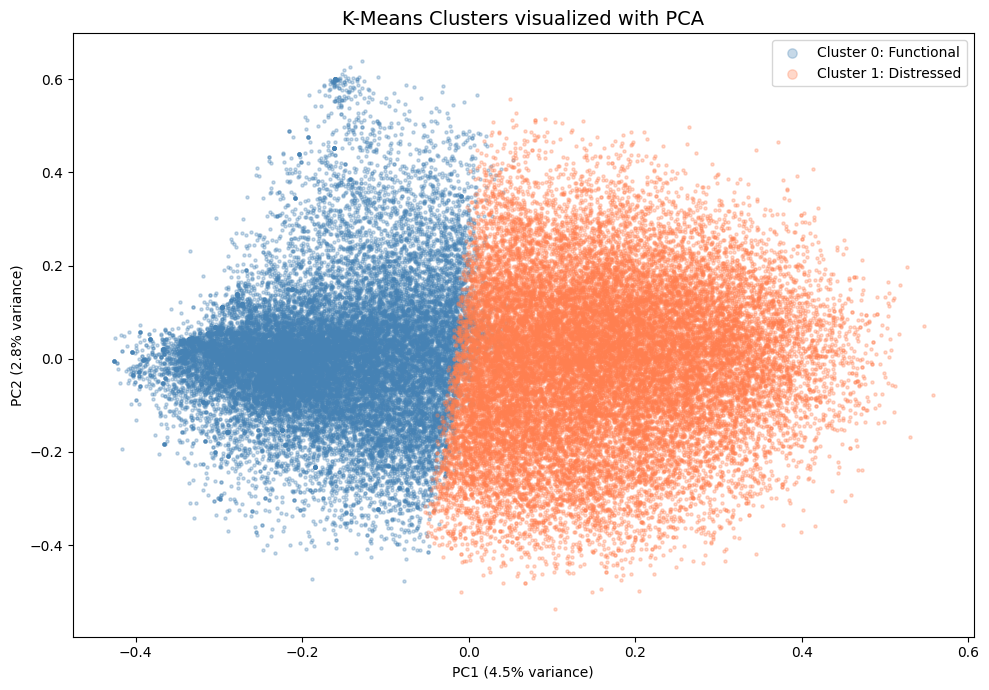

Saved!


In [38]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_lsa)

# Add to dataframe
df['pca_x'] = X_2d[:, 0]
df['pca_y'] = X_2d[:, 1]

# Plot clusters
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'coral']
labels = ['Cluster 0: Functional', 'Cluster 1: Distressed']

for i in range(2):
    mask = df['cluster'] == i
    plt.scatter(df.loc[mask, 'pca_x'], 
                df.loc[mask, 'pca_y'],
                c=colors[i], label=labels[i], 
                alpha=0.3, s=5)

plt.title('K-Means Clusters visualized with PCA', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/kmeans_clusters_pca.png', dpi=150)
plt.show()
print("Saved!")

In [39]:
# Save progress
df.to_csv('/home/guts/mental_health_nlp/data/preprocessed.csv', index=False)
print("Saved!")

Saved!


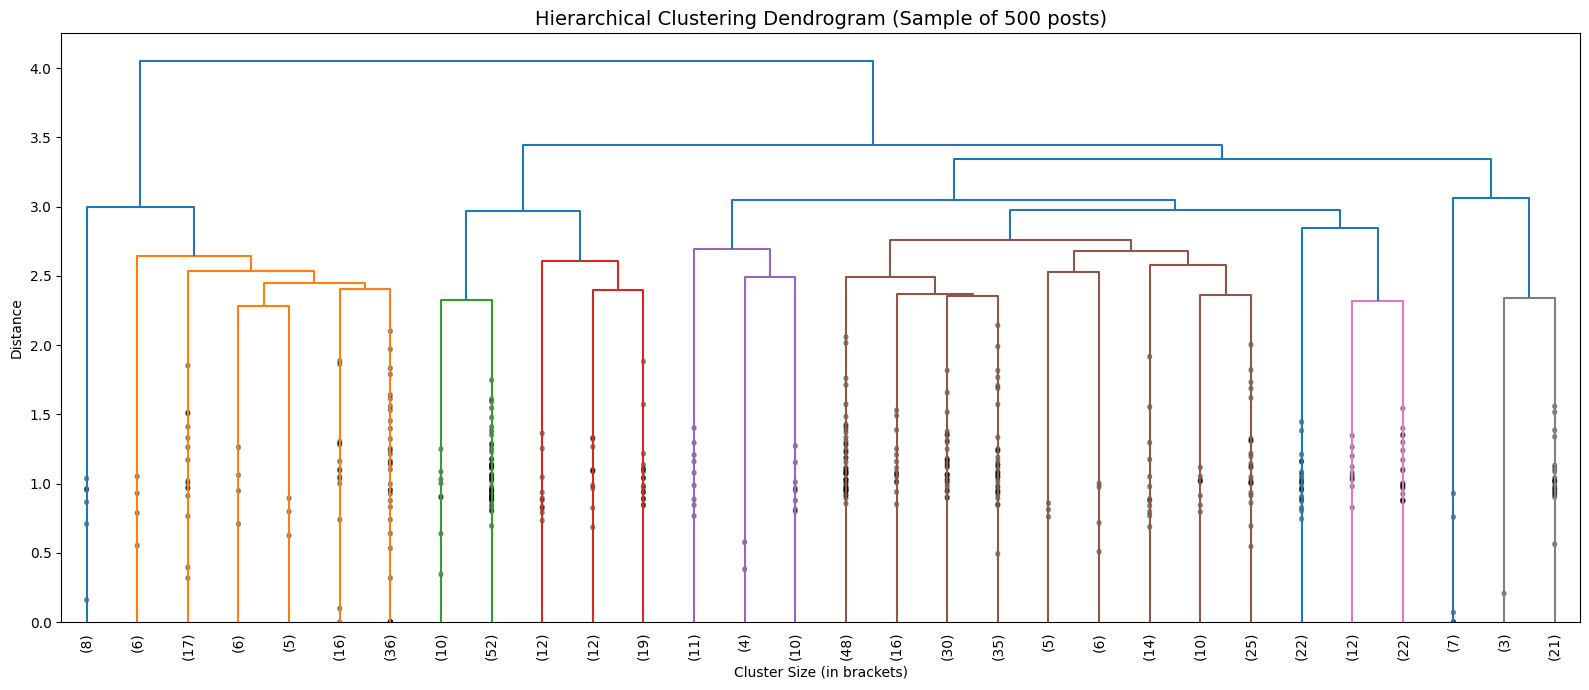

Saved!


In [40]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

# Sample 500 posts for dendrogram (full dataset is too large to visualize)
sample_idx = np.random.RandomState(42).choice(len(X_lsa), 500, replace=False)
X_sample = X_lsa[sample_idx]
labels_sample = df['status'].iloc[sample_idx].values

# Build linkage matrix
linked = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 7))
dendrogram(
    linked,
    truncate_mode='lastp',  # show only last p merged clusters
    p=30,                   # show last 30 merges
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Sample of 500 posts)', fontsize=14)
plt.xlabel('Cluster Size (in brackets)')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/dendrogram.png', dpi=150)
plt.show()
print("Saved!")

In [41]:
# Use a sample of 2000 rows - agglomerative can't handle full dataset
sample_idx = np.random.RandomState(42).choice(len(X_lsa), 2000, replace=False)
X_sample_agg = X_lsa[sample_idx]

# Apply Agglomerative Clustering on sample
agg_cluster = AgglomerativeClustering(n_clusters=2)
agg_labels = agg_cluster.fit_predict(X_sample_agg)

# Get corresponding kmeans labels for same sample
kmeans_sample_labels = df['cluster'].iloc[sample_idx].values
status_sample_labels = df['status'].iloc[sample_idx].values

print("Agglomerative Cluster distribution:")
import pandas as pd
print(pd.Series(agg_labels).value_counts())

print("\nAgglomerative vs Mental Health Status:")
print(pd.crosstab(agg_labels, status_sample_labels))

print("\nAgreement between KMeans and Agglomerative:")
agreement = (kmeans_sample_labels == agg_labels).mean()
print(f"{agreement*100:.1f}% of posts assigned to same cluster")

Agglomerative Cluster distribution:
0    1522
1     478
Name: count, dtype: int64

Agglomerative vs Mental Health Status:
col_0  Anxiety  Bipolar  Depression  Normal  Personality disorder  Stress  \
row_0                                                                       
0          107      101         545     306                    40      96   
1           33        9          68     313                     4      11   

col_0  Suicidal  
row_0            
0           327  
1            40  

Agreement between KMeans and Agglomerative:
30.9% of posts assigned to same cluster


In [42]:
# Flip agglomerative labels and recalculate
agg_labels_flipped = 1 - agg_labels
agreement_flipped = (kmeans_sample_labels == agg_labels_flipped).mean()
print(f"Agreement after fixing label flip: {agreement_flipped*100:.1f}%")

Agreement after fixing label flip: 69.0%


In [43]:
from sklearn.cluster import DBSCAN

# DBSCAN on LSA matrix
# eps = maximum distance between two points to be considered neighbors
# min_samples = minimum points to form a dense cluster
dbscan = DBSCAN(eps=0.5, min_samples=5, metric='cosine', n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_lsa)

# Results
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f"Number of clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print("\nCluster distribution:")
print(pd.Series(dbscan_labels).value_counts().head(10))

Number of clusters found: 1
Noise points: 780 (1.5%)

Cluster distribution:
 0    51704
-1      780
Name: count, dtype: int64


In [44]:
# Try different eps values
for eps in [0.3, 0.4, 0.5, 0.6, 0.7]:
    db = DBSCAN(eps=eps, min_samples=5, metric='cosine', n_jobs=-1)
    labels = db.fit_predict(X_lsa)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_nois = (labels == -1).sum()
    print(f"eps={eps} | Clusters: {n_clust} | Noise: {n_nois} ({n_nois/len(labels)*100:.1f}%)")

eps=0.3 | Clusters: 56 | Noise: 21437 (40.8%)
eps=0.4 | Clusters: 6 | Noise: 2192 (4.2%)
eps=0.5 | Clusters: 1 | Noise: 780 (1.5%)
eps=0.6 | Clusters: 1 | Noise: 719 (1.4%)
eps=0.7 | Clusters: 1 | Noise: 719 (1.4%)


In [45]:
# Train final DBSCAN with eps=0.4
dbscan_final = DBSCAN(eps=0.4, min_samples=5, metric='cosine', n_jobs=-1)
df['dbscan_cluster'] = dbscan_final.fit_predict(X_lsa)

n_clusters = len(set(df['dbscan_cluster'])) - 1
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {(df['dbscan_cluster']==-1).sum()}")

print("\nCluster distribution:")
print(df['dbscan_cluster'].value_counts())

print("\nDBSCAN Clusters vs Mental Health Status:")
print(pd.crosstab(df['dbscan_cluster'], df['status']))

Clusters found: 6
Noise points: 2192

Cluster distribution:
dbscan_cluster
 0    50262
-1     2192
 2       10
 1        5
 3        5
 4        5
 5        5
Name: count, dtype: int64

DBSCAN Clusters vs Mental Health Status:
status          Anxiety  Bipolar  Depression  Normal  Personality disorder  \
dbscan_cluster                                                               
-1                   51       63         429    1131                     5   
 0                 3790     2714       14974   14990                  1072   
 1                    0        0           0       5                     0   
 2                    0        0           0      10                     0   
 3                    0        0           0       5                     0   
 4                    0        0           0       5                     0   
 5                    0        0           0       5                     0   

status          Stress  Suicidal  
dbscan_cluster                    


In [46]:
# Look at what makes noise posts unusual
noise_posts = df[df['dbscan_cluster'] == -1]

print("Noise points by status:")
print(noise_posts['status'].value_counts())

print("\nSample noise posts (unusual/outlier posts):")
for status in ['Suicidal', 'Normal', 'Depression']:
    print(f"\n--- {status} outliers ---")
    samples = noise_posts[noise_posts['status']==status]['statement'].sample(3, random_state=42)
    for s in samples:
        print(f"• {s[:120]}")

Noise points by status:
status
Normal                  1131
Depression               429
Suicidal                 400
Stress                   113
Bipolar                   63
Anxiety                   51
Personality disorder       5
Name: count, dtype: int64

Sample noise posts (unusual/outlier posts):

--- Suicidal outliers ---
• I wish something would just take me out. Its been 23 yrs of depression and suicidal ideation. I want to build a cocoon a
• I am all alone and it hurts. I am doing this because it is best for everyone else. It will end their stress. I never wan
• I was not scared. I felt relieved. My psychiatrist is considering putting me into a psychiatric ward because I am having

--- Normal outliers ---
• So the now: we had been commiserating for a while about our shitty exes and stress, and about 3 weeks ago I was on a dat
• it certainly is.
• SARAAAAAH —£

--- Depression outliers ---
• You gave your all only for it fail. Why bother? You finally got your dream job then la

In [47]:
# Save final dataframe with all cluster labels
df.to_csv('/home/guts/mental_health_nlp/data/preprocessed.csv', index=False)

# Save models
import joblib
joblib.dump(kmeans_final, '/home/guts/mental_health_nlp/models/kmeans_final.pkl')
joblib.dump(dbscan_final, '/home/guts/mental_health_nlp/models/dbscan_final.pkl')
joblib.dump(tfidf, '/home/guts/mental_health_nlp/models/tfidf.pkl')
joblib.dump(lsa, '/home/guts/mental_health_nlp/models/lsa.pkl')

print("All models saved!")

# Clustering summary
print("\n=== CLUSTERING SUMMARY ===")
print(f"KMeans (k=2)        → Functional vs Distressed language")
print(f"Agglomerative (k=2) → Same 2 groups, 69% agreement with KMeans")
print(f"DBSCAN (eps=0.4)    → 1 main cluster + outlier detection")

All models saved!

=== CLUSTERING SUMMARY ===
KMeans (k=2)        → Functional vs Distressed language
Agglomerative (k=2) → Same 2 groups, 69% agreement with KMeans
DBSCAN (eps=0.4)    → 1 main cluster + outlier detection


In [48]:
from sklearn.decomposition import PCA
import numpy as np

# Fit PCA on LSA matrix
pca_full = PCA(n_components=10, random_state=42)
X_pca = pca_full.fit_transform(X_lsa)

# How much variance does each component explain?
print("Variance explained by each component:")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    cumvar = pca_full.explained_variance_ratio_[:i+1].sum()
    print(f"PC{i+1}: {var*100:.2f}% (cumulative: {cumvar*100:.2f}%)")

Variance explained by each component:
PC1: 4.52% (cumulative: 4.52%)
PC2: 2.80% (cumulative: 7.32%)
PC3: 2.39% (cumulative: 9.72%)
PC4: 1.96% (cumulative: 11.68%)
PC5: 1.89% (cumulative: 13.57%)
PC6: 1.72% (cumulative: 15.29%)
PC7: 1.67% (cumulative: 16.96%)
PC8: 1.60% (cumulative: 18.56%)
PC9: 1.49% (cumulative: 20.05%)
PC10: 1.44% (cumulative: 21.49%)


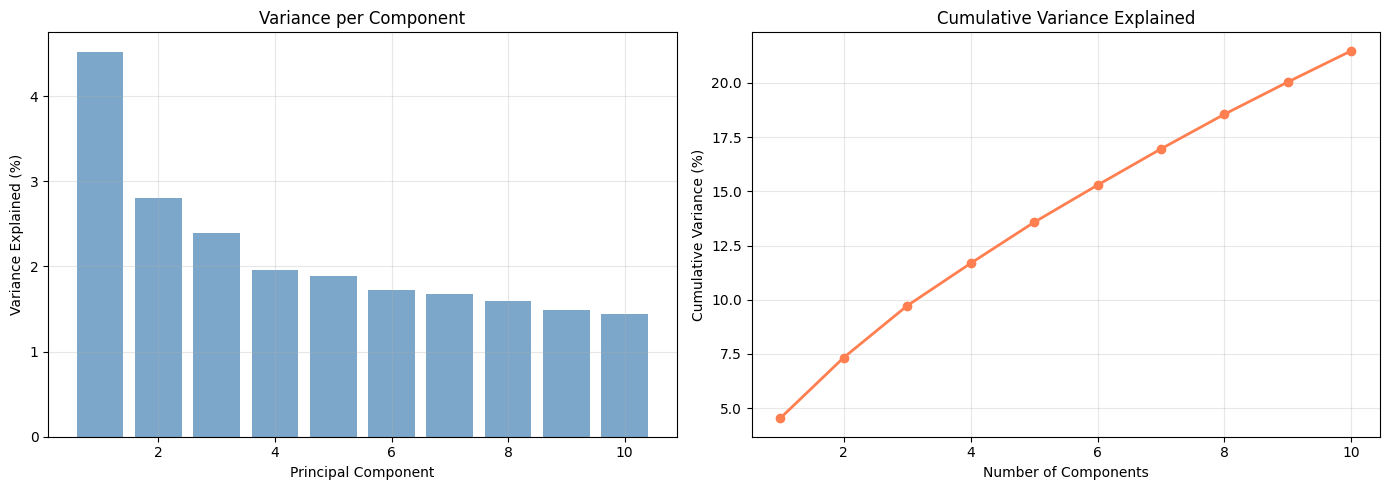

Saved!


In [53]:
# Visualize variance explained
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

components = range(1, 11)
ax1.bar(components, pca_full.explained_variance_ratio_*100, color='steelblue', alpha=0.7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('Variance per Component')
ax1.grid(True, alpha=0.3)

cumvar = np.cumsum(pca_full.explained_variance_ratio_*100)
ax2.plot(components, cumvar, marker='o', color='coral', linewidth=2)
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Variance Explained')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/pca_variance.png', dpi=150)
plt.show()
print("Saved!")

In [54]:
# Get the SVD component (before normalizer) to interpret PCA directions
svd_component = lsa.named_steps['truncatedsvd']
feature_names = tfidf.get_feature_names_out()

print("=== PC1 - What drives the most variation? ===")
pc1 = svd_component.components_[0]
top_positive = [feature_names[i] for i in pc1.argsort()[-15:]][::-1]
top_negative = [feature_names[i] for i in pc1.argsort()[:15]]
print(f"Positive direction: {', '.join(top_positive)}")
print(f"Negative direction: {', '.join(top_negative)}")

print("\n=== PC2 - Second dimension of variation ===")
pc2 = svd_component.components_[1]
top_positive = [feature_names[i] for i in pc2.argsort()[-15:]][::-1]
top_negative = [feature_names[i] for i in pc2.argsort()[:15]]
print(f"Positive direction: {', '.join(top_positive)}")
print(f"Negative direction: {', '.join(top_negative)}")

=== PC1 - What drives the most variation? ===
Positive direction: feel, like, want, get, know, life, think, go, time, make, even, really, people, would, day
Negative direction: perdedorsoy, como, jyp, wallsim, uma, mais, por, une, soy, pression, und, ich, mas, est, tier

=== PC2 - Second dimension of variation ===
Positive direction: want, die, kill, anymore, live, hate, life, tired, fuck, fucking, love, care, wish, end, someone
Negative direction: feel, get, anxiety, like, depression, work, day, start, time, week, year, stress, month, symptom, go


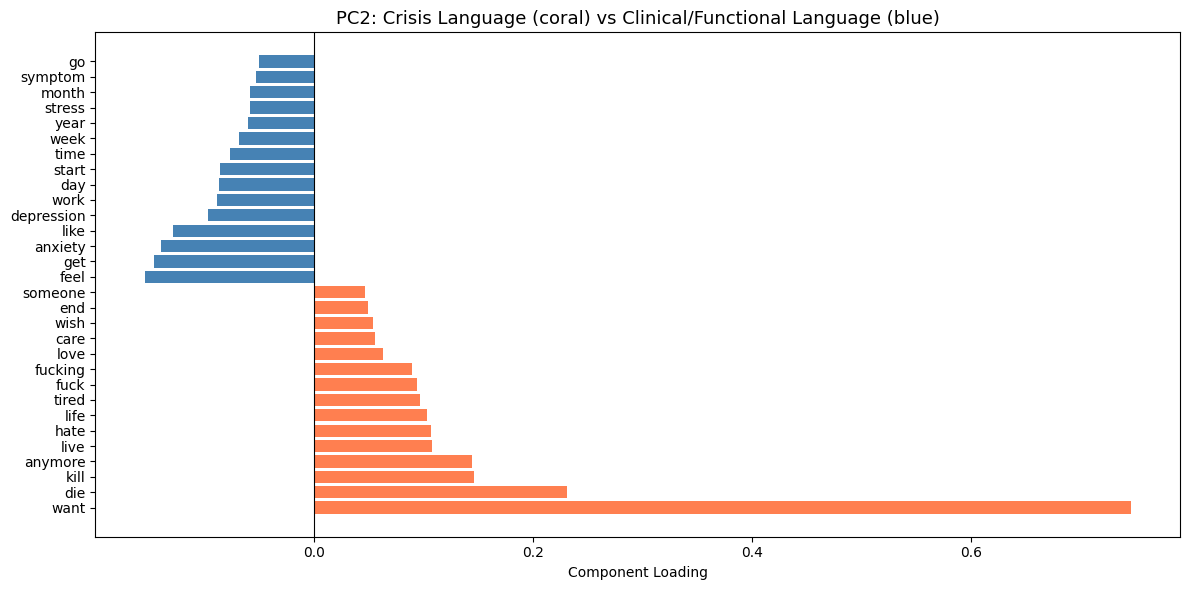

Saved!


In [51]:
# Plot PC2 interpretation
fig, ax = plt.subplots(figsize=(12, 6))

pc2 = svd_component.components_[1]
top_idx = list(pc2.argsort()[-15:][::-1]) + list(pc2.argsort()[:15])
top_words = [feature_names[i] for i in top_idx]
top_values = [pc2[i] for i in top_idx]
colors = ['coral' if v > 0 else 'steelblue' for v in top_values]

ax.barh(top_words, top_values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('PC2: Crisis Language (coral) vs Clinical/Functional Language (blue)', fontsize=13)
ax.set_xlabel('Component Loading')
plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/pca_pc2_interpretation.png', dpi=150)
plt.show()
print("Saved!")

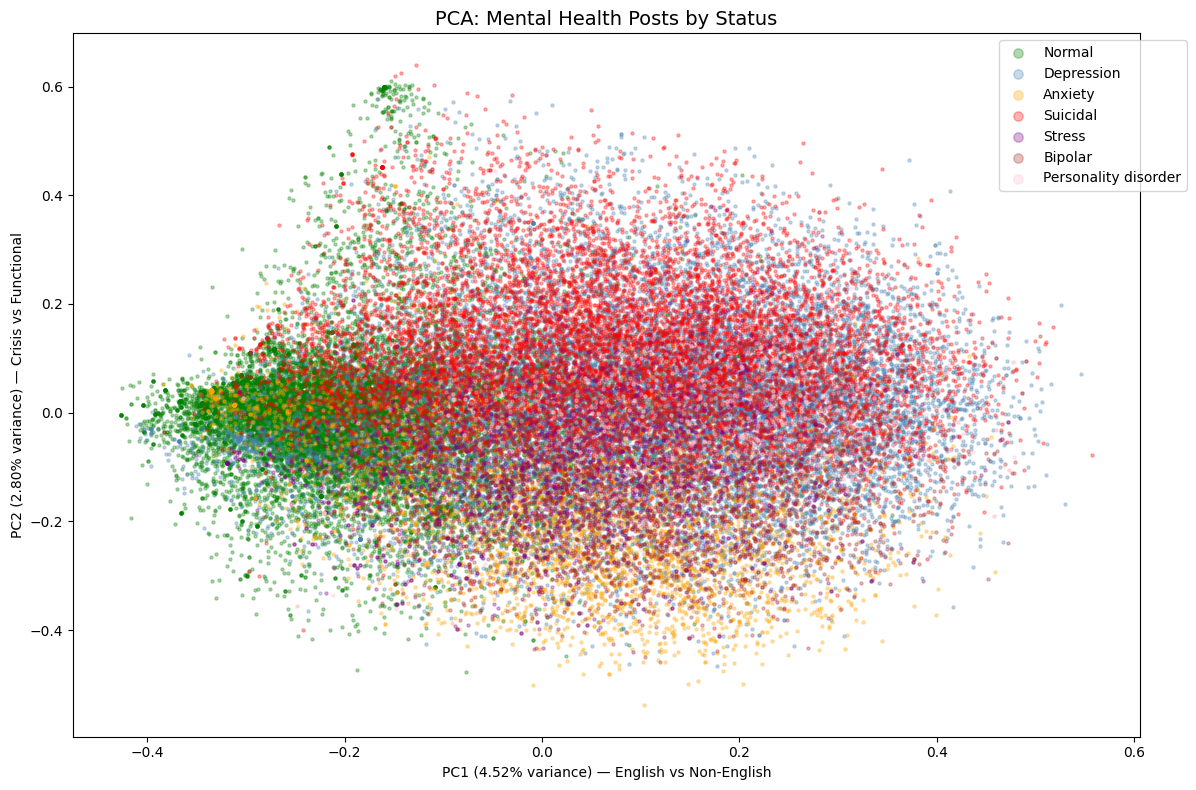

Saved!


In [52]:
# PCA scatter colored by status
fig, ax = plt.subplots(figsize=(12, 8))

colors_map = {
    'Normal': 'green',
    'Depression': 'steelblue', 
    'Anxiety': 'orange',
    'Suicidal': 'red',
    'Stress': 'purple',
    'Bipolar': 'brown',
    'Personality disorder': 'pink'
}

for status, color in colors_map.items():
    mask = df['status'] == status
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=status,
               alpha=0.3, s=5)

ax.set_xlabel(f'PC1 (4.52% variance) — English vs Non-English')
ax.set_ylabel(f'PC2 (2.80% variance) — Crisis vs Functional')
ax.set_title('PCA: Mental Health Posts by Status', fontsize=14)
ax.legend(markerscale=3, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/pca_by_status.png', dpi=150)
plt.show()
print("Saved!")

In [56]:
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import numpy as np

# Use raw TF-IDF but reduce to top 500 features for Factor Analysis
tfidf_fa = TfidfVectorizer(max_features=500)
X_fa_input = tfidf_fa.fit_transform(df['cleaned']).toarray()
feature_names_fa = tfidf_fa.get_feature_names_out()

# Apply Factor Analysis
fa = FactorAnalysis(n_components=5, random_state=42, max_iter=1000)
X_fa = fa.fit_transform(X_fa_input)

print("Factor Analysis complete!")
print("\n=== LATENT PSYCHOLOGICAL DIMENSIONS ===")
for i in range(5):
    factor = fa.components_[i]
    top_positive = [feature_names_fa[j] for j in factor.argsort()[-10:]][::-1]
    top_negative = [feature_names_fa[j] for j in factor.argsort()[:10]]
    print(f"\nFactor {i+1}:")
    print(f"  High: {', '.join(top_positive)}")
    print(f"  Low:  {', '.join(top_negative)}")

Factor Analysis complete!

=== LATENT PSYCHOLOGICAL DIMENSIONS ===

Factor 1:
  High: feel, like, get, life, year, know, even, time, thing, would
  Low:  yes, morning, miss, buy, today, god, tomorrow, please, damn, amp

Factor 2:
  High: anxiety, symptom, week, doctor, experience, health, start, attack, bipolar, panic
  Low:  want, life, live, anymore, friend, people, die, hate, fuck, kill

Factor 3:
  High: feel, like, people, anyone, someone, depression, bipolar, talk, else, help
  Low:  year, day, get, job, work, week, go, school, last, month

Factor 4:
  High: feel, pain, attack, sleep, heart, die, panic, want, go, wake
  Low:  depression, mental, job, help, work, people, bipolar, money, year, therapy

Factor 5:
  High: anxiety, health, die, mental, pain, kill, fuck, want, fucking, suicide
  Low:  feel, like, really, day, time, friend, start, episode, new, sad


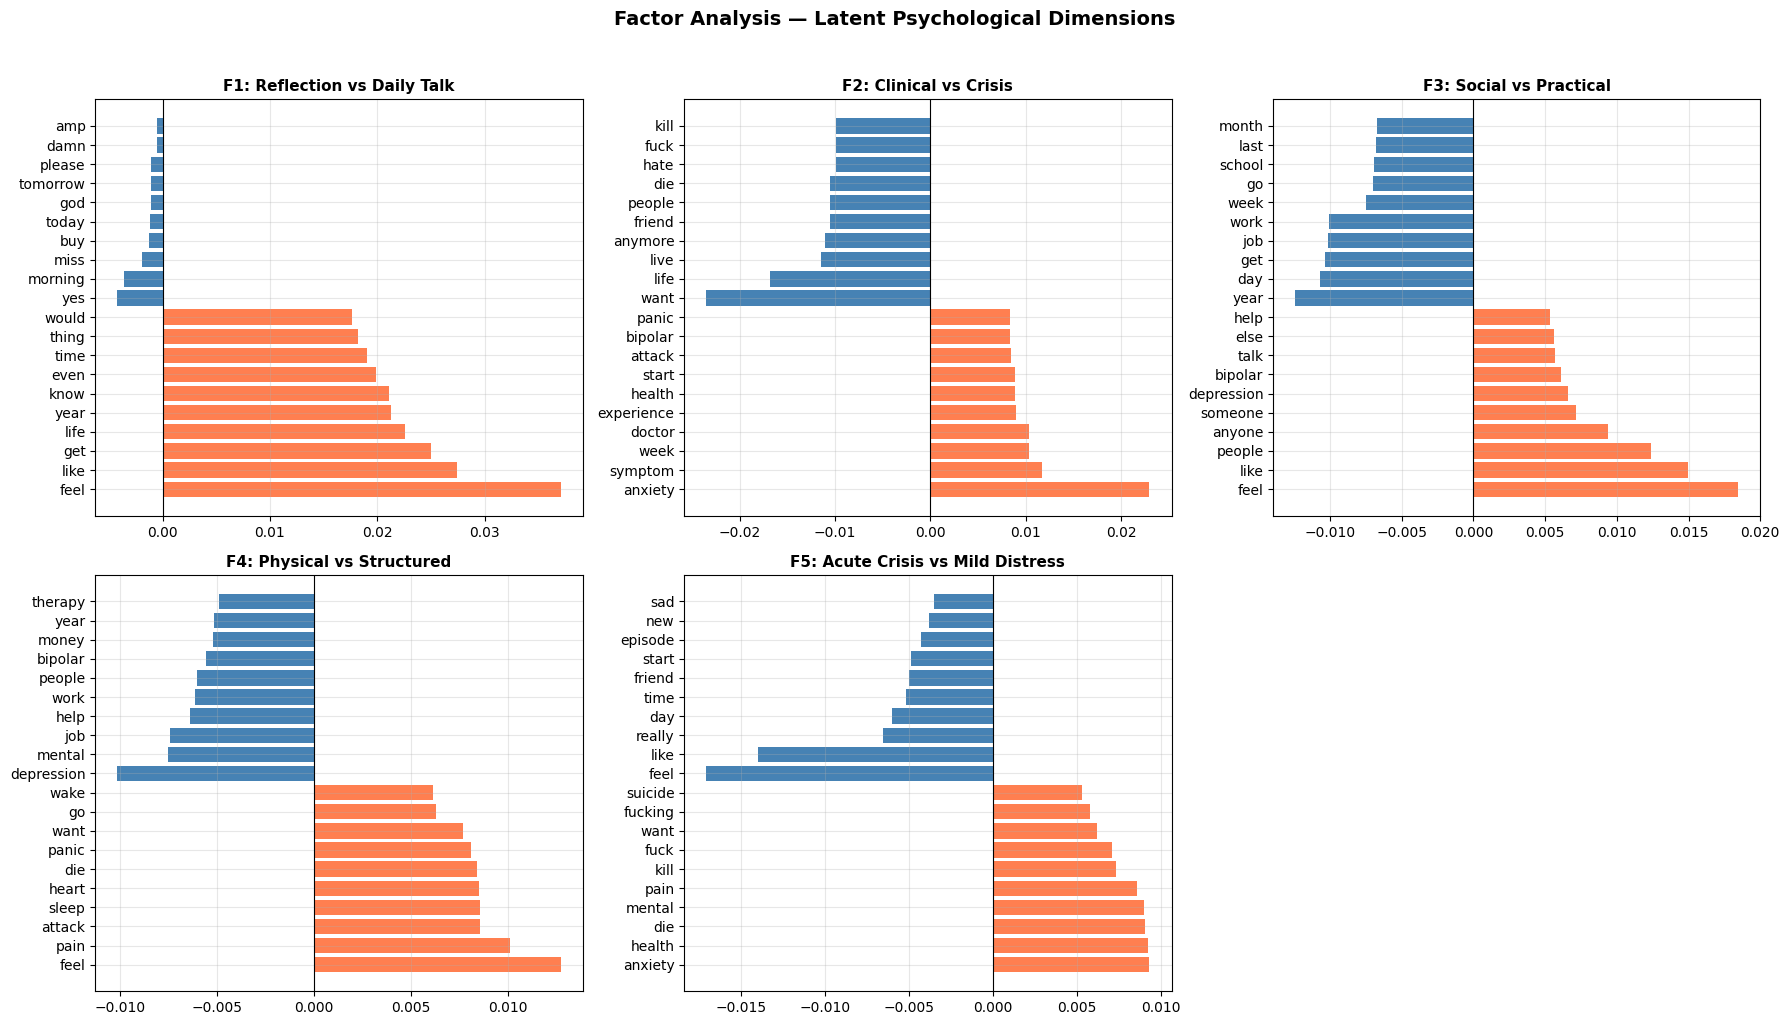

Saved!


In [57]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

factor_names = [
    'F1: Reflection vs Daily Talk',
    'F2: Clinical vs Crisis',
    'F3: Social vs Practical',
    'F4: Physical vs Structured',
    'F5: Acute Crisis vs Mild Distress'
]

for i in range(5):
    factor = fa.components_[i]
    top_idx = list(factor.argsort()[-10:][::-1]) + list(factor.argsort()[:10])
    words = [feature_names_fa[j] for j in top_idx]
    values = [factor[j] for j in top_idx]
    colors = ['coral' if v > 0 else 'steelblue' for v in values]
    
    axes[i].barh(words, values, color=colors)
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    axes[i].set_title(factor_names[i], fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

axes[5].axis('off')
plt.suptitle('Factor Analysis — Latent Psychological Dimensions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/factor_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [58]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Define mental health keywords to track
keywords = [
    'anxiety', 'panic', 'sleep', 'insomnia', 'depression', 
    'suicide', 'die', 'kill', 'stress', 'work', 'pain', 
    'heart', 'tired', 'alone', 'help', 'therapy', 'medication',
    'friend', 'family', 'cry', 'hate', 'fear', 'hopeless',
    'worthless', 'empty', 'numb', 'anger', 'sad', 'happy'
]

# Convert each post into a basket of present keywords
def get_keywords(text):
    words = set(text.split())
    return [kw for kw in keywords if kw in words]

baskets = df['cleaned'].apply(get_keywords)

# Remove empty baskets
baskets = baskets[baskets.apply(len) > 0]
print(f"Posts with at least one keyword: {len(baskets)}")
print(f"\nSample basket: {baskets.iloc[0]}")

Posts with at least one keyword: 33398

Sample basket: ['sleep', 'heart']


In [59]:
# Encode baskets into binary matrix
te = TransactionEncoder()
te_array = te.fit_transform(baskets)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print("Basket matrix shape:", basket_df.shape)

# Run Apriori - find frequent itemsets
frequent_itemsets = apriori(
    basket_df, 
    min_support=0.01,    # keyword combo must appear in at least 1% of posts
    use_colnames=True
)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print("\nTop 10 most frequent:")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Basket matrix shape: (33398, 29)
Frequent itemsets found: 292

Top 10 most frequent:
     support      itemsets
13  0.256033        (help)
26  0.244176        (work)
9   0.230523      (friend)
4   0.185400  (depression)
2   0.166477     (anxiety)
5   0.164471         (die)
7   0.152794      (family)
15  0.134230        (kill)
11  0.128511        (hate)
21  0.118929       (sleep)


In [60]:
# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.2,
    num_itemsets=len(frequent_itemsets)
)

# Sort by lift
rules = rules.sort_values('lift', ascending=False)

# Clean up for display
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"Rules found: {len(rules)}")
print("\nTop 20 strongest associations:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20).to_string())

Rules found: 796

Top 20 strongest associations:
            antecedents         consequents   support  confidence      lift
196             therapy          medication  0.012156    0.192417  3.843508
197          medication             therapy  0.012156    0.242823  3.843508
790        work, friend        help, family  0.013354    0.196909  3.723886
787        help, family        work, friend  0.013354    0.252548  3.723886
786        work, family        help, friend  0.013354    0.265793  3.654566
791        help, friend        work, family  0.013354    0.183615  3.654566
40              anxiety               panic  0.024043    0.144424  3.196480
41                panic             anxiety  0.024043    0.532140  3.196480
792              family  work, help, friend  0.013354    0.087400  3.095409
785  work, help, friend              family  0.013354    0.472959  3.095409
457             therapy    depression, work  0.010031    0.158768  3.093656
456    depression, work             the

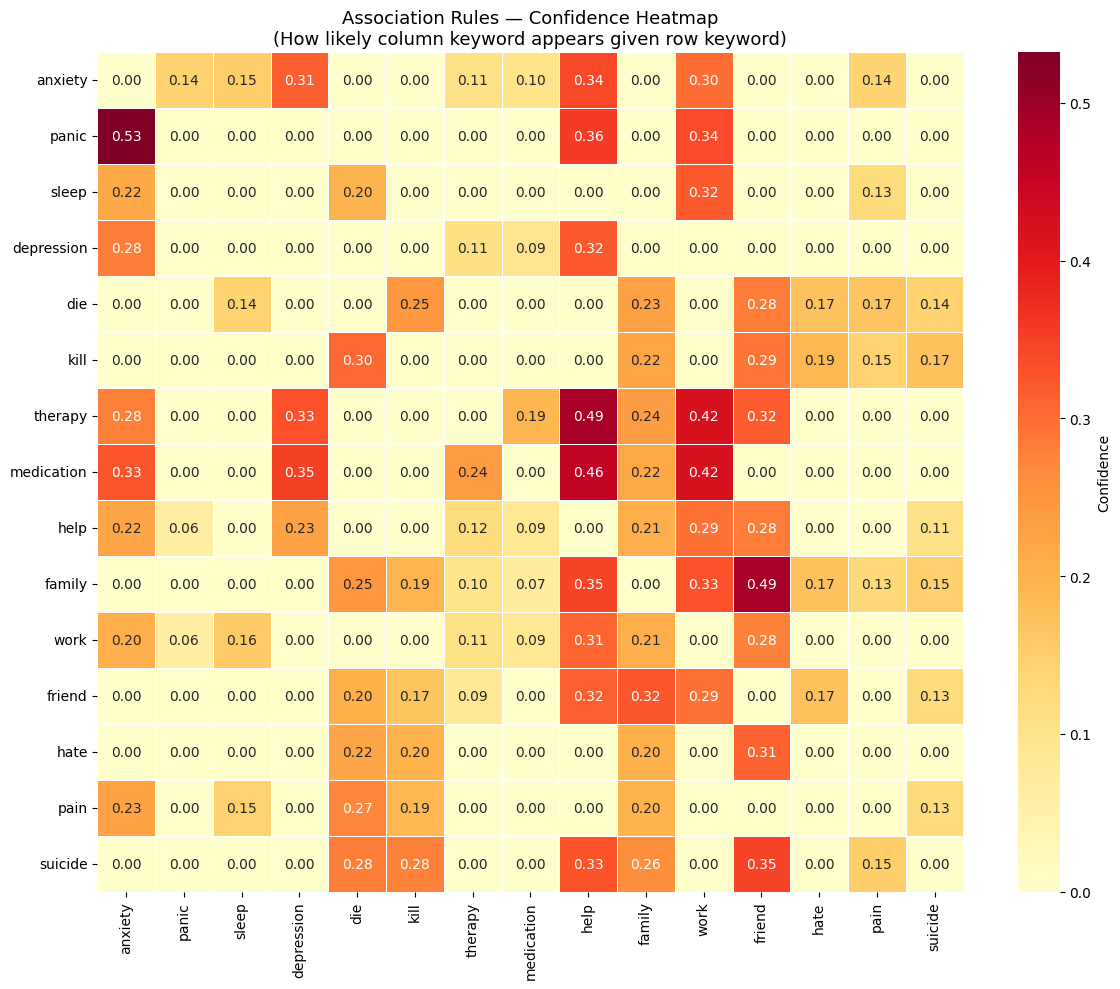

Saved!


In [61]:
# Create confidence heatmap for top keywords
top_keywords = ['anxiety', 'panic', 'sleep', 'depression', 'die', 
                'kill', 'therapy', 'medication', 'help', 'family',
                'work', 'friend', 'hate', 'pain', 'suicide']

# Build confidence matrix
conf_matrix = pd.DataFrame(0.0, index=top_keywords, columns=top_keywords)

for _, rule in rules.iterrows():
    ant = rule['antecedents']
    con = rule['consequents']
    if ant in top_keywords and con in top_keywords:
        conf_matrix.loc[ant, con] = rule['confidence']

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Confidence'}
)
plt.title('Association Rules — Confidence Heatmap\n(How likely column keyword appears given row keyword)', 
          fontsize=13)
plt.tight_layout()
plt.savefig('/home/guts/mental_health_nlp/notebooks/association_rules_heatmap.png', dpi=150)
plt.show()
print("Saved!")

In [62]:
# Save rules
rules.to_csv('/home/guts/mental_health_nlp/data/association_rules.csv', index=False)

# Save final dataframe
df.to_csv('/home/guts/mental_health_nlp/data/preprocessed.csv', index=False)

print("=== PROJECT COMPLETION STATUS ===")
print("Data Collection & Preprocessing")
print("Topic Modeling (LDA) — 3 topics found")
print("K-Means Clustering — 2 clusters (Functional vs Distressed)")
print("Hierarchical Clustering — confirmed 2 main groups")
print("DBSCAN — outlier detection, flagged crisis posts")
print("PCA — discovered Crisis vs Functional language axis")
print("Factor Analysis — 5 psychological dimensions")
print("Association Rule Mining — 796 rules, therapy↔medication strongest")
print("\nAll techniques complete! Ready for final report.")

=== PROJECT COMPLETION STATUS ===
Data Collection & Preprocessing
Topic Modeling (LDA) — 3 topics found
K-Means Clustering — 2 clusters (Functional vs Distressed)
Hierarchical Clustering — confirmed 2 main groups
DBSCAN — outlier detection, flagged crisis posts
PCA — discovered Crisis vs Functional language axis
Factor Analysis — 5 psychological dimensions
Association Rule Mining — 796 rules, therapy↔medication strongest

All techniques complete! Ready for final report.
